# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [37]:
df = pd.read_csv('../Bank_raw/bank-full.csv', sep=";")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [38]:
df.shape

(45211, 17)

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [40]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [41]:
df.describe(include="object")

,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
unique,12,3,4,2,2,2,3,12,4,2
top,blue-collar,married,secondary,no,yes,no,cellular,may,unknown,no
freq,9732,27214,23202,44396,25130,37967,29285,13766,36959,39922


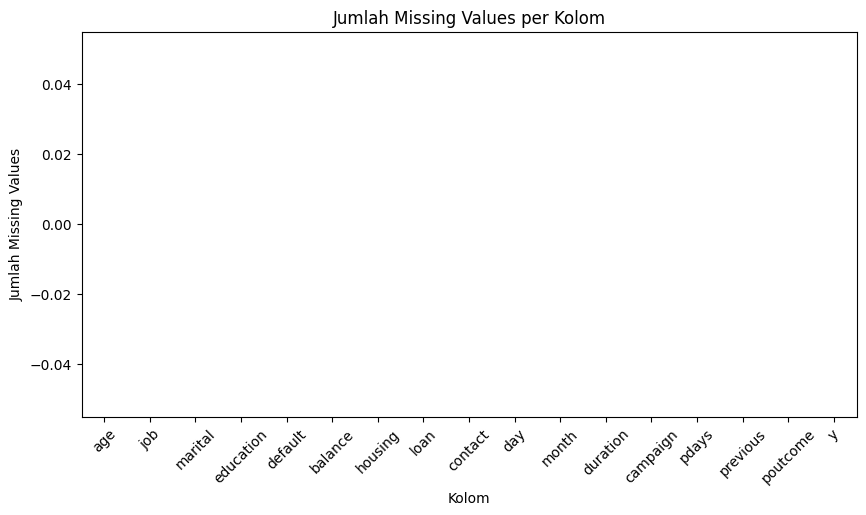

In [42]:
missing_values = df.isnull().sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=missing_values.index, y=missing_values)
plt.title("Jumlah Missing Values per Kolom")
plt.xlabel("Kolom")
plt.ylabel("Jumlah Missing Values")
plt.xticks(rotation=45)
plt.show()

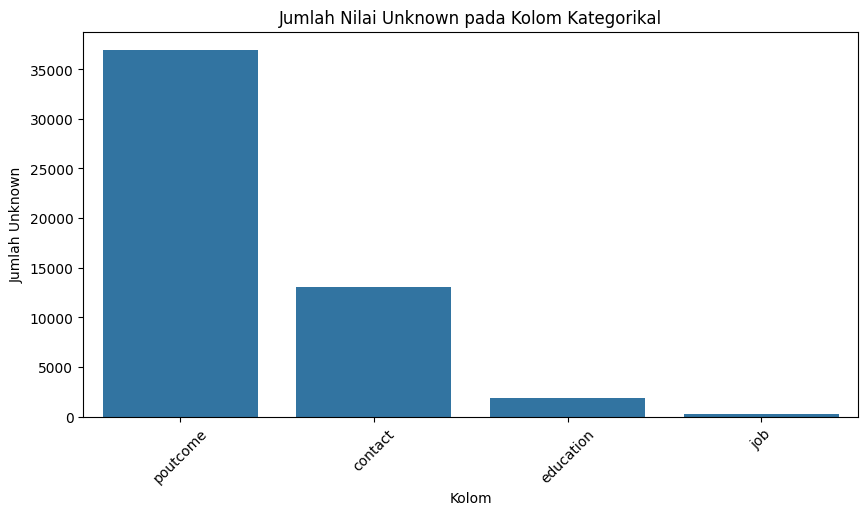

In [43]:
categorical_colums = df.select_dtypes(include='object').columns.tolist()

unknown_counts = {}

for col in categorical_colums:
    unknown_counts[col] = (df[col] == "unknown").sum()

unknown_df = pd.DataFrame({
    "column" : list(unknown_counts.keys()),
    "unknown_counts" : list(unknown_counts.values())
})

unknown_df["unknown_percentage"] = (unknown_df["unknown_counts"] / len(df) * 100).round(2)
unknown_df = unknown_df.sort_values(by="unknown_percentage", ascending=False)

unknown_plot = unknown_df[unknown_df["unknown_counts"] > 0]

plt.figure(figsize=(10, 5))
sns.barplot(data=unknown_plot, x="column", y="unknown_counts")
plt.title("Jumlah Nilai Unknown pada Kolom Kategorikal")
plt.xlabel("Kolom")
plt.ylabel("Jumlah Unknown")
plt.xticks(rotation=45)
plt.show()

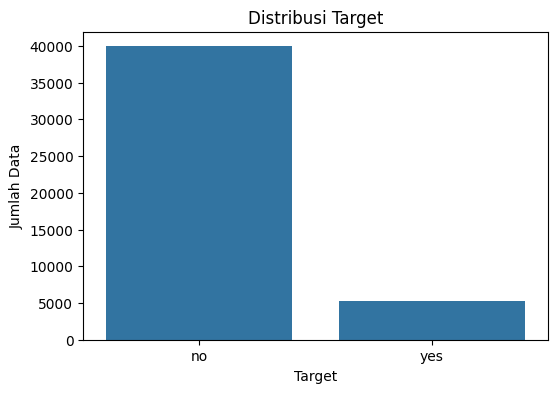

In [44]:
target_counts = df["y"].value_counts()
target_percentage = df["y"].value_counts(normalize=True) * 100

target_df = pd.DataFrame({
    "target": target_counts.index,
    "count": target_counts.values,
    "percentage": target_percentage.values.round(2)
})

target_df

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="y")
plt.title("Distribusi Target")
plt.xlabel("Target")
plt.ylabel("Jumlah Data")
plt.show()

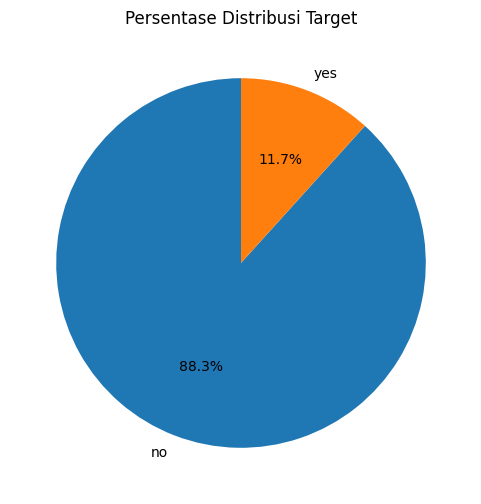

In [45]:
plt.figure(figsize=(6, 6))
plt.pie(
    target_counts,
    labels=target_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Persentase Distribusi Target")
plt.show()

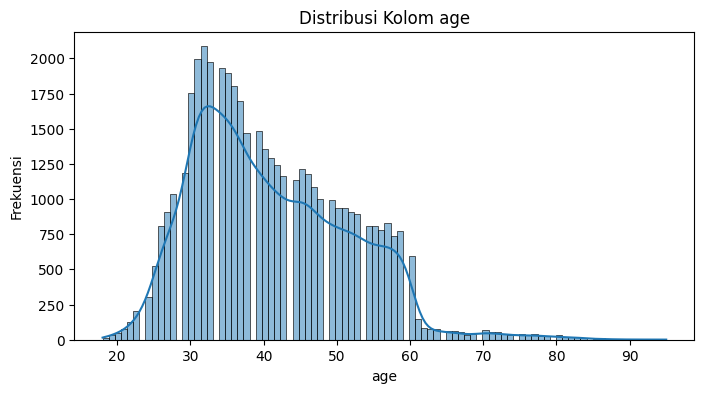

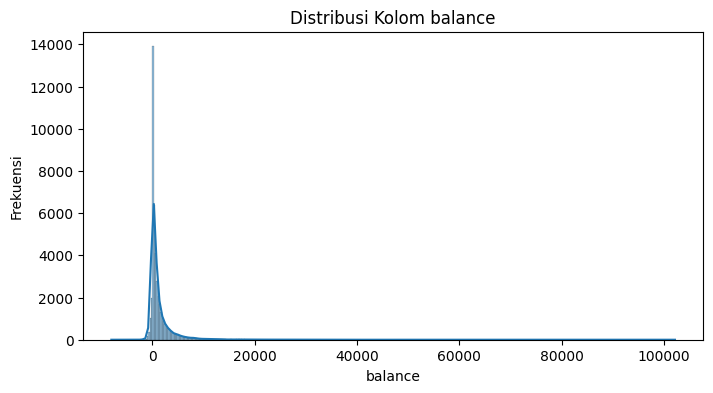

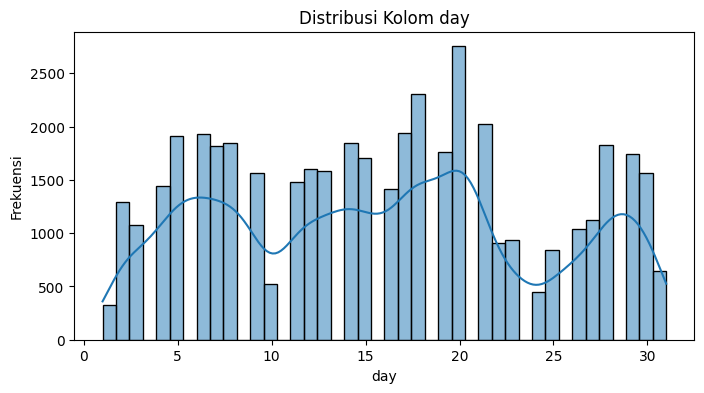

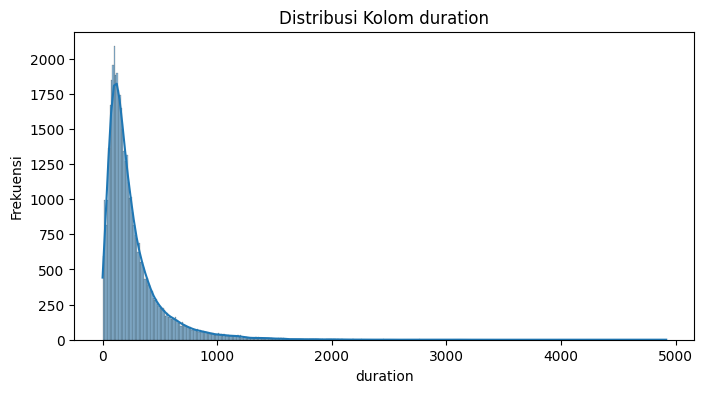

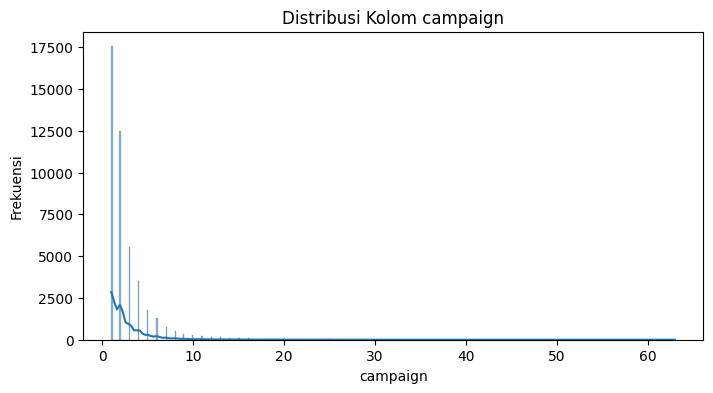

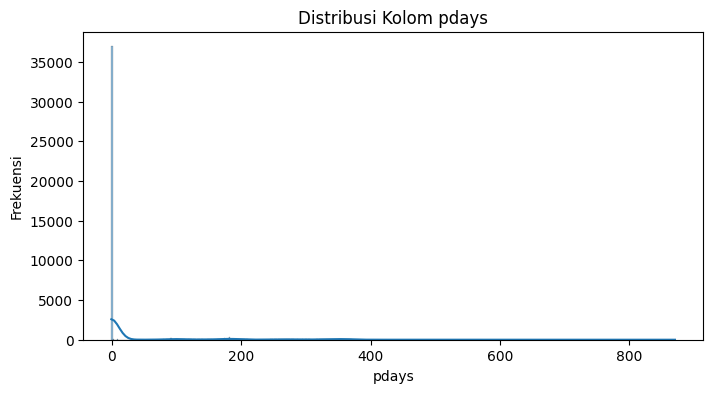

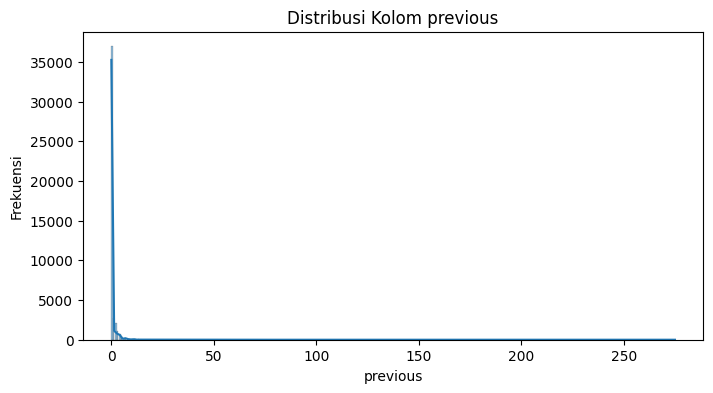

In [46]:
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

for col in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribusi Kolom {col}")
    plt.xlabel(col)
    plt.ylabel("Frekuensi")
    plt.show()

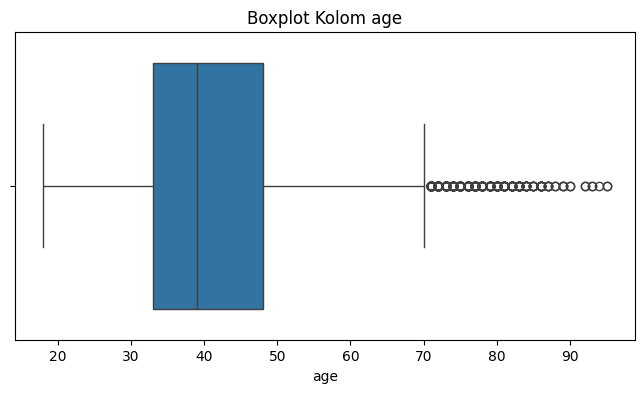

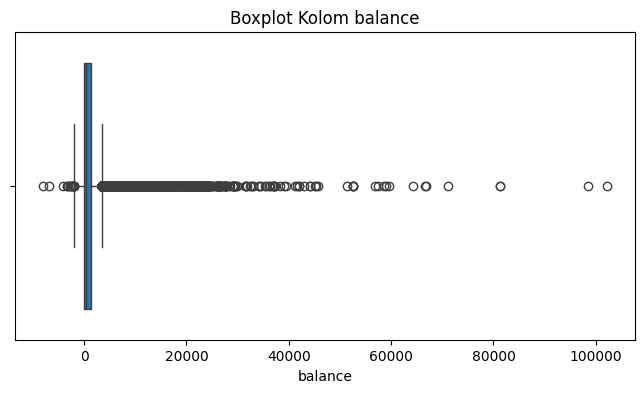

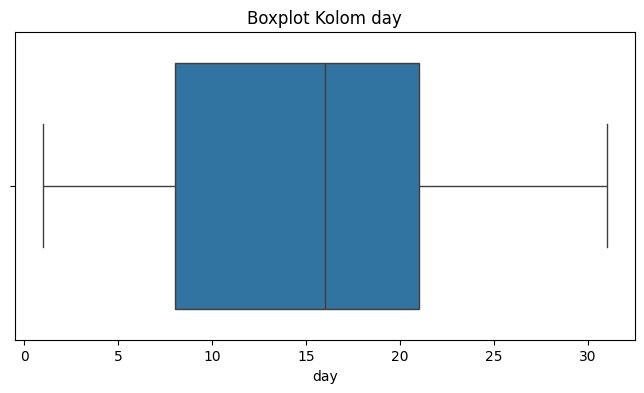

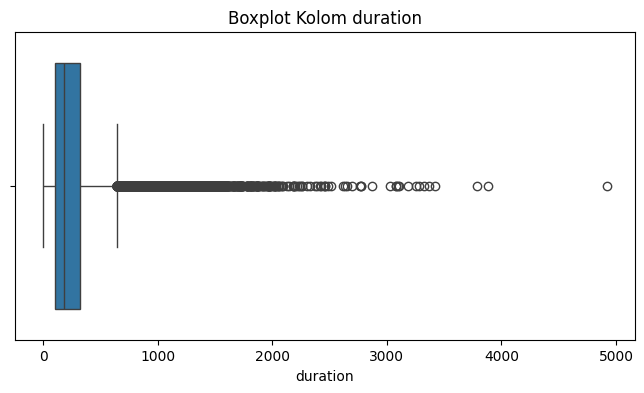

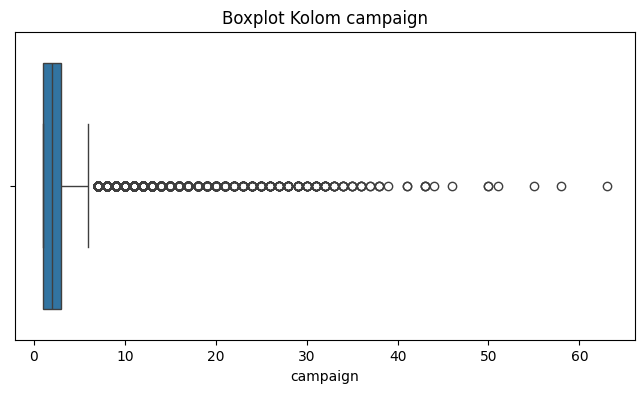

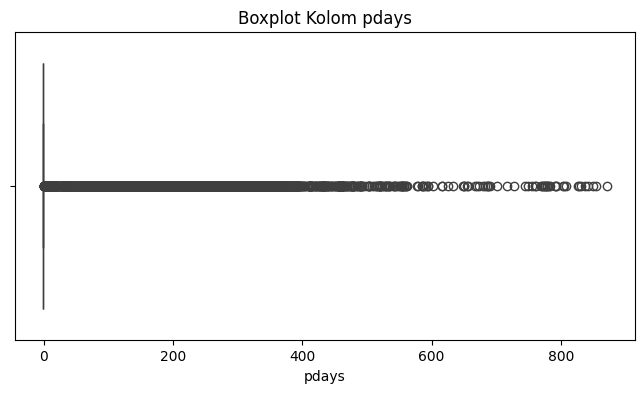

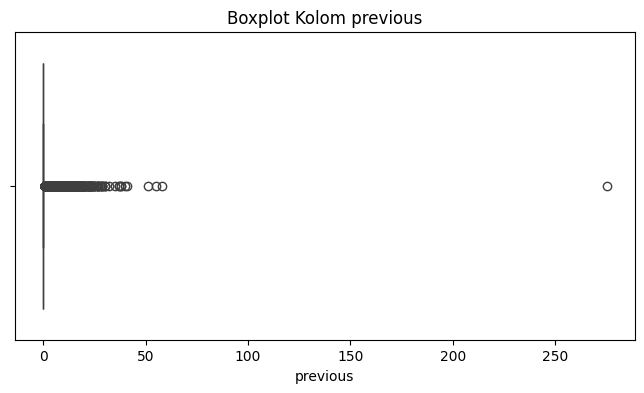

In [47]:
for col in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot Kolom {col}")
    plt.xlabel(col)
    plt.show()

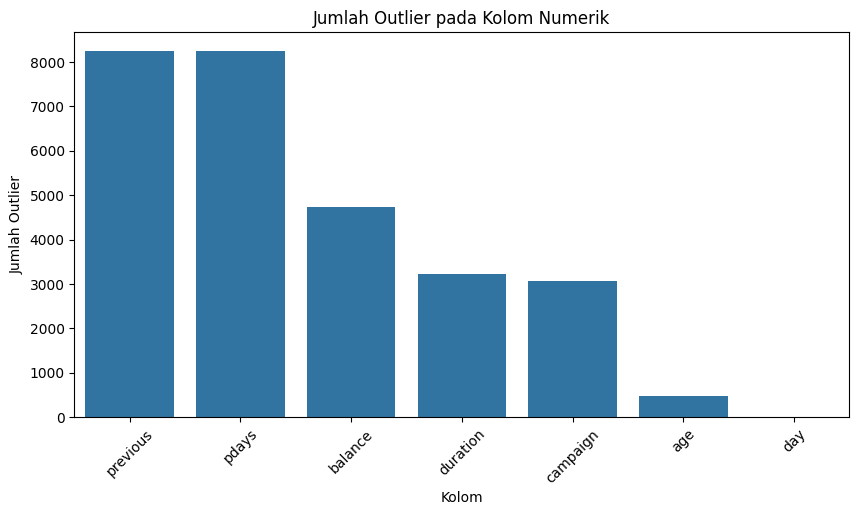

In [48]:
outlier_summary = []

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    outlier_percentage = outlier_count / len(df) * 100

    outlier_summary.append({
        "column": col,
        "outlier_count": outlier_count,
        "outlier_percentage": round(outlier_percentage, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df = outlier_df.sort_values(by="outlier_count", ascending=False)

outlier_df


plt.figure(figsize=(10, 5))
sns.barplot(data=outlier_df, x="column", y="outlier_count")
plt.title("Jumlah Outlier pada Kolom Numerik")
plt.xlabel("Kolom")
plt.ylabel("Jumlah Outlier")
plt.xticks(rotation=45)
plt.show()

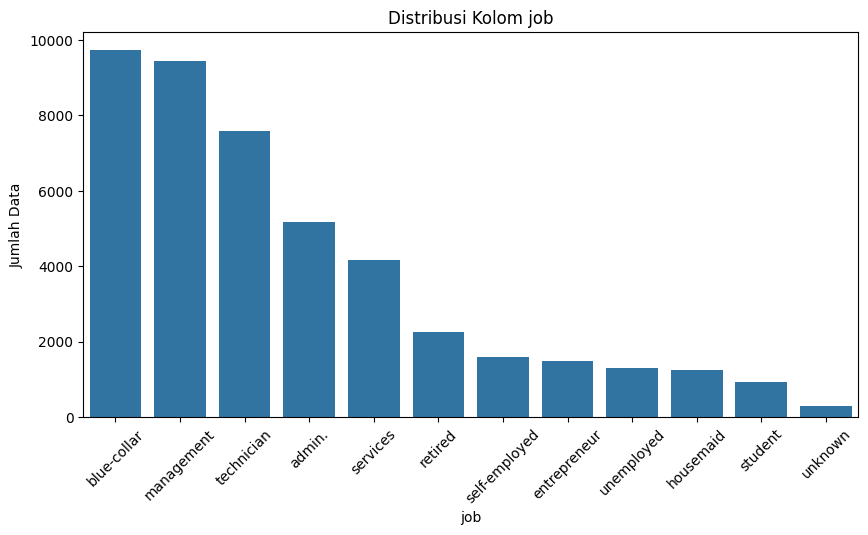

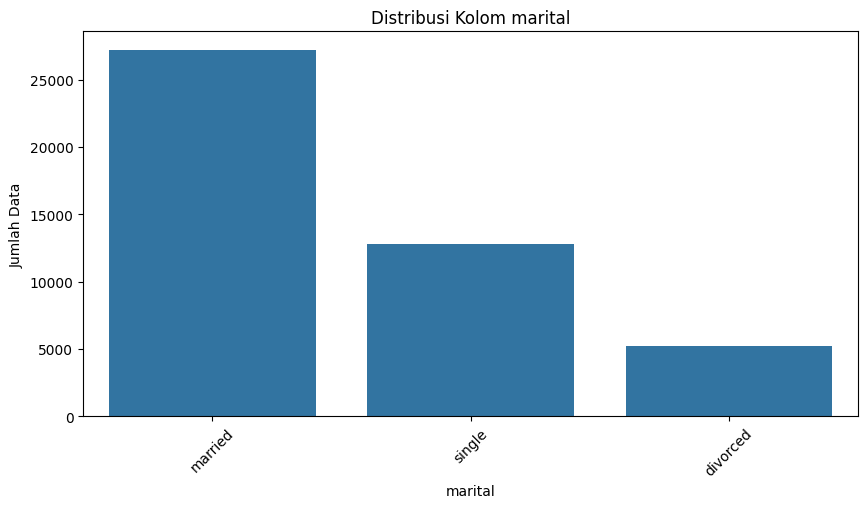

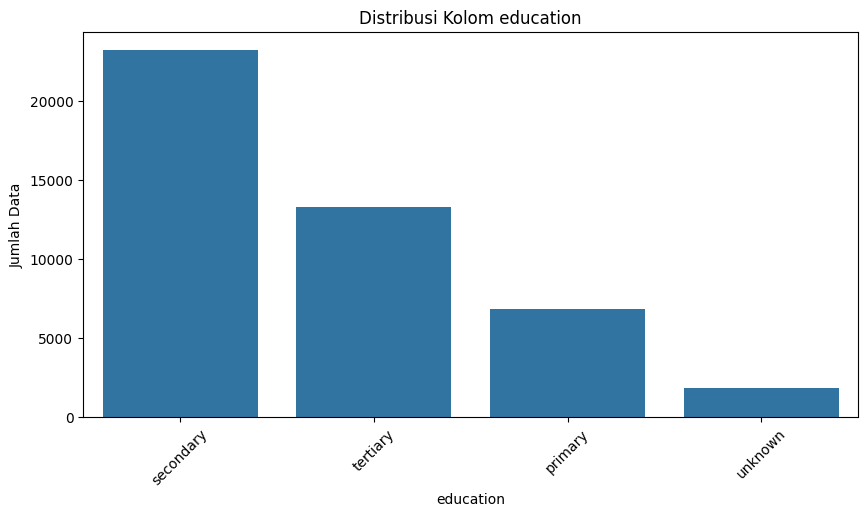

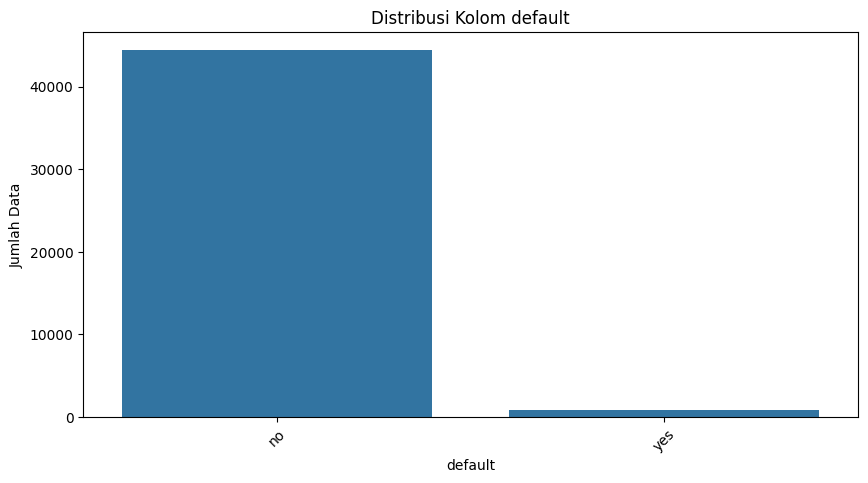

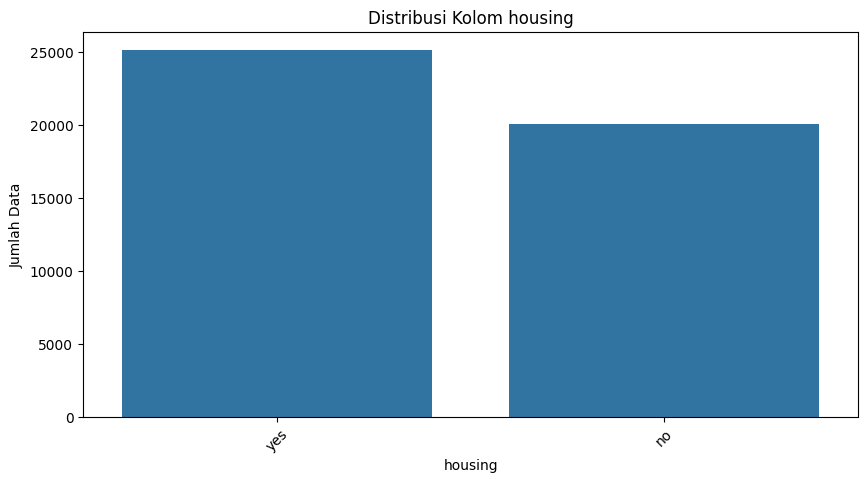

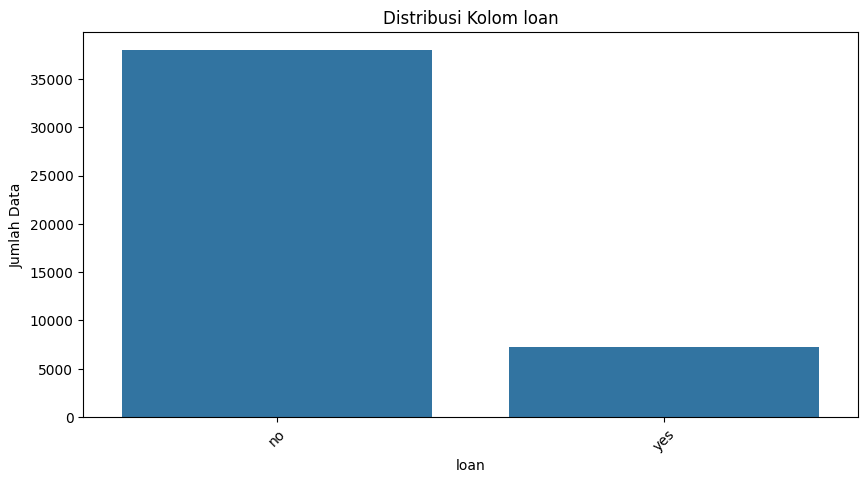

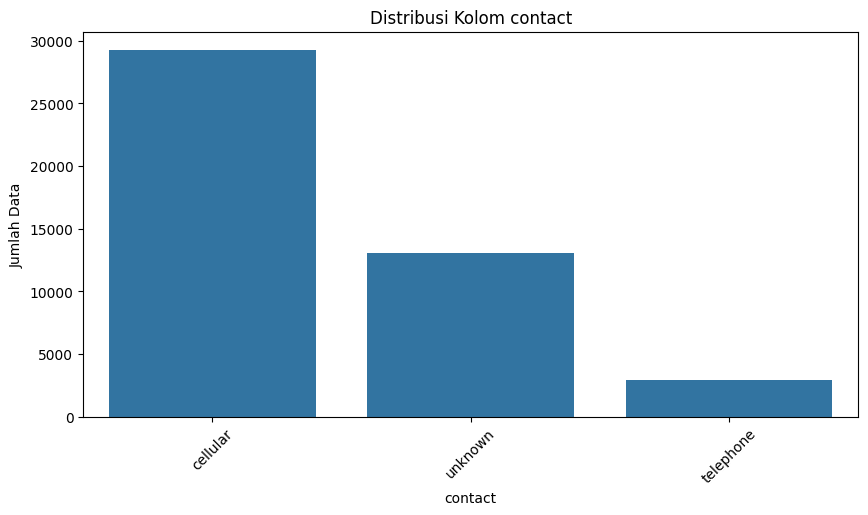

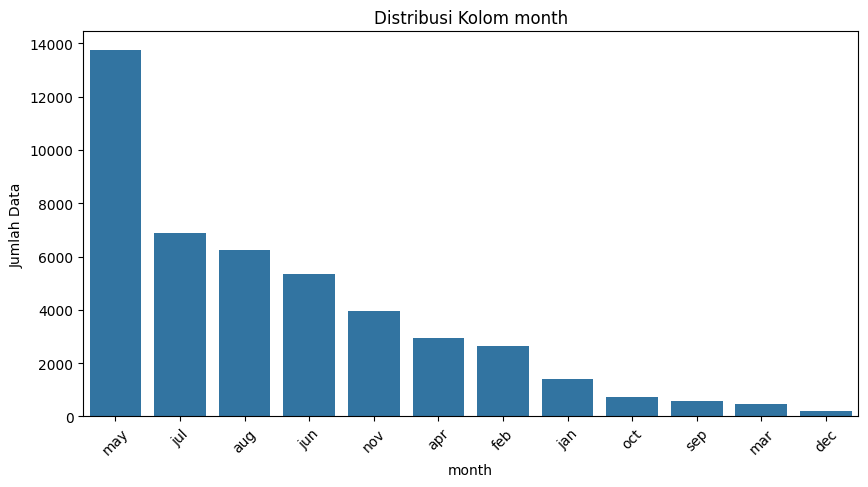

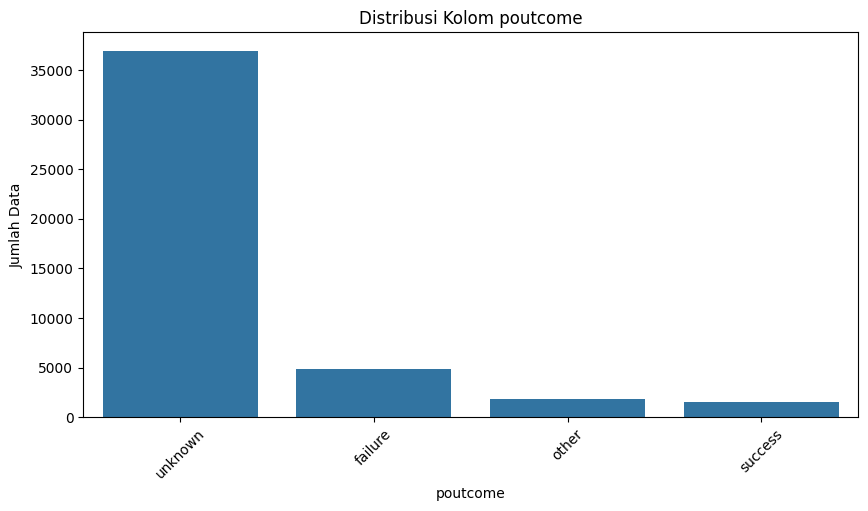

In [49]:
categorical_features = [col for col in categorical_colums if col != "y"]

for col in categorical_features:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f"Distribusi Kolom {col}")
    plt.xlabel(col)
    plt.ylabel("Jumlah Data")
    plt.xticks(rotation=45)
    plt.show()

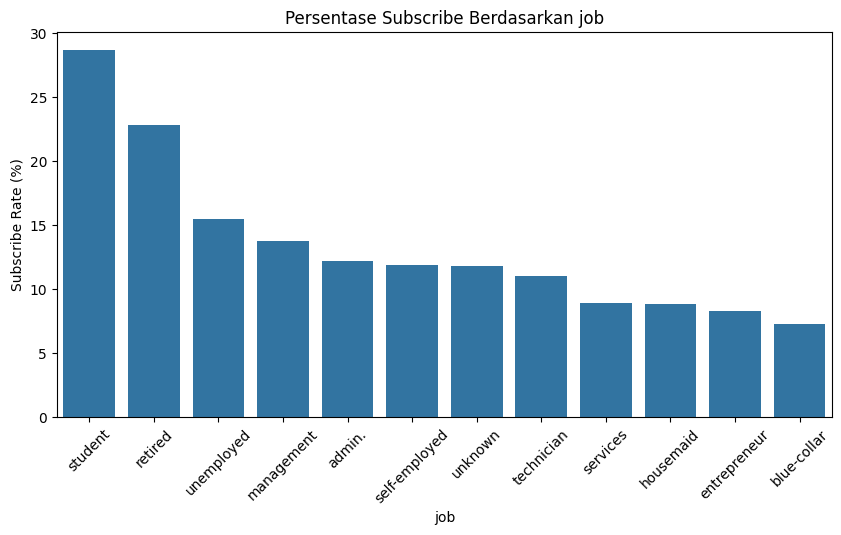

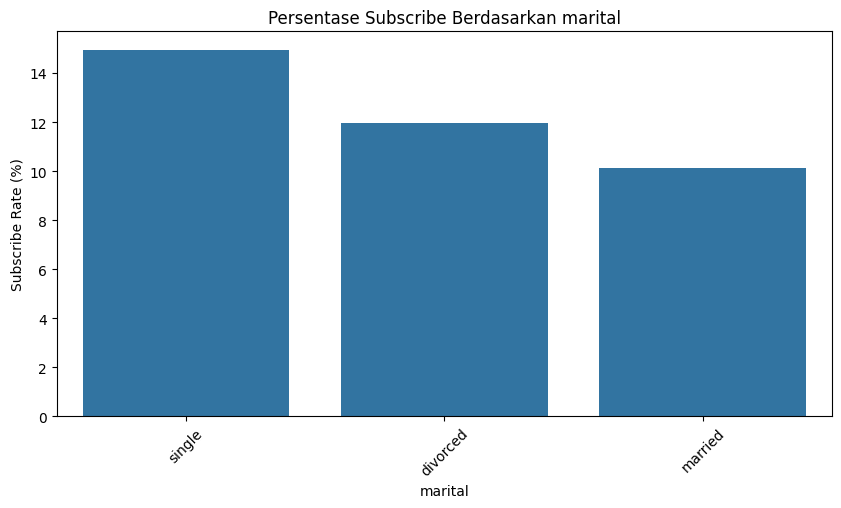

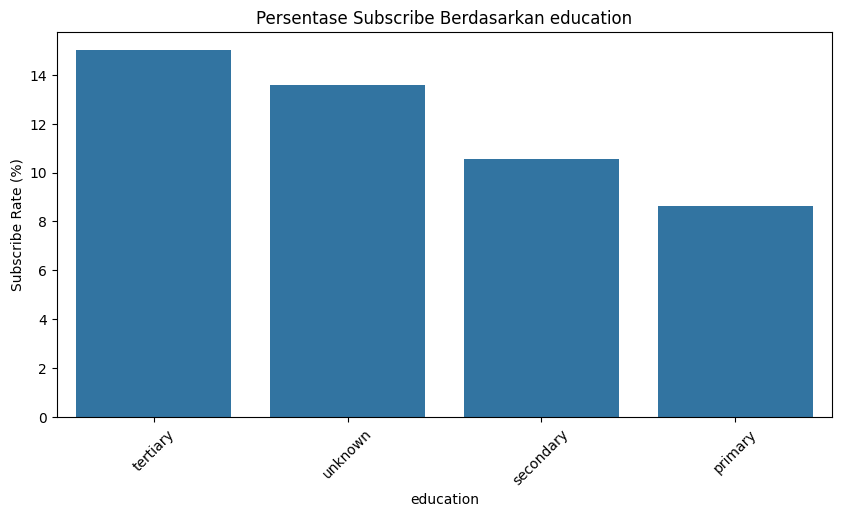

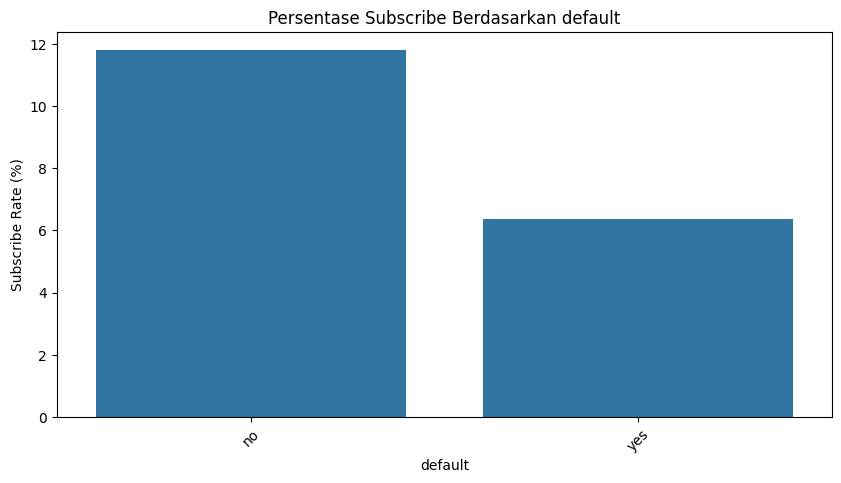

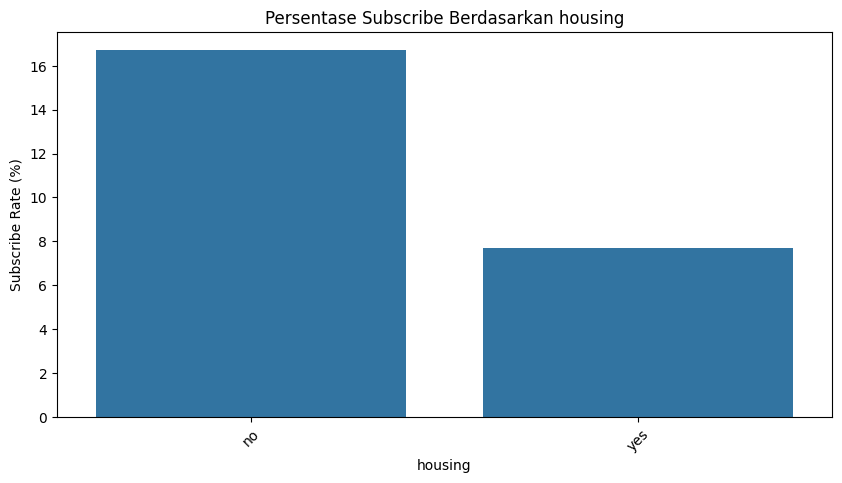

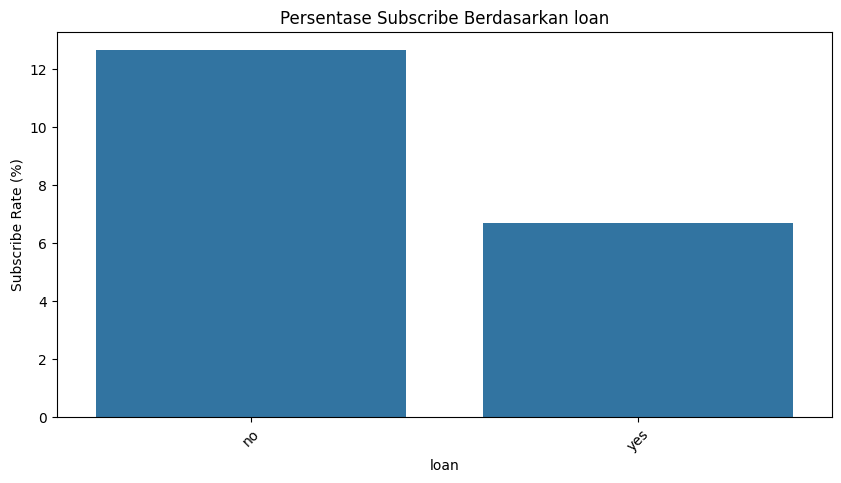

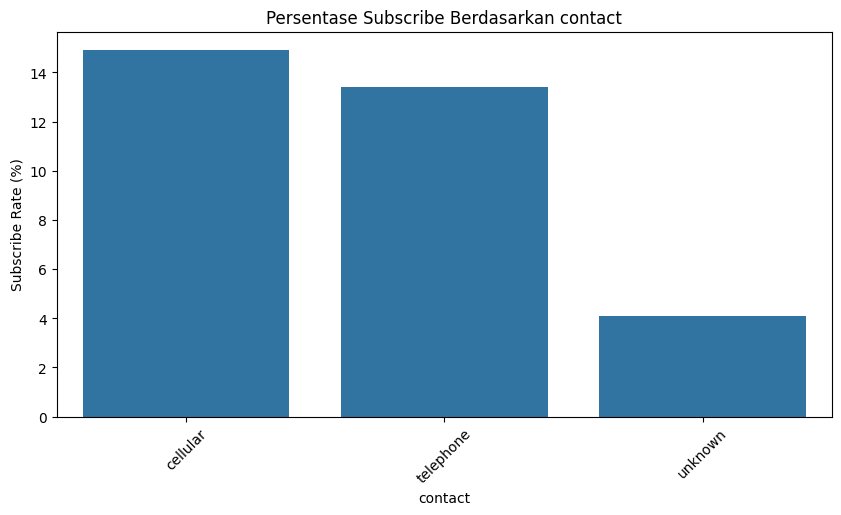

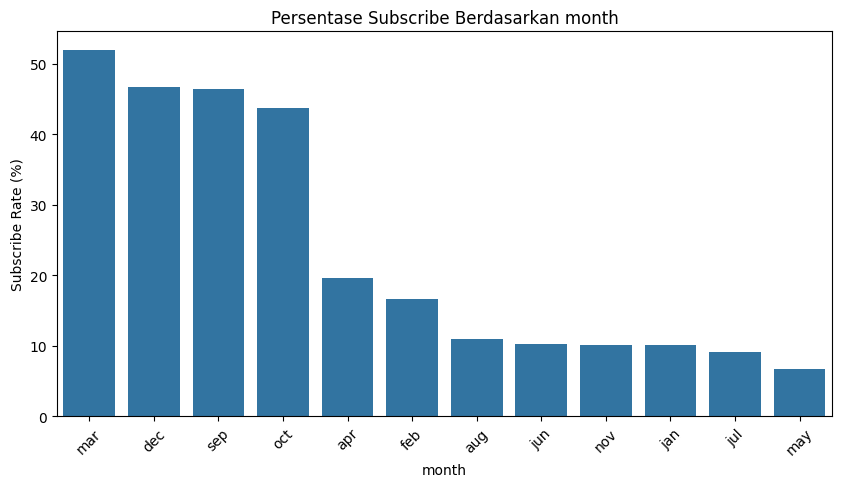

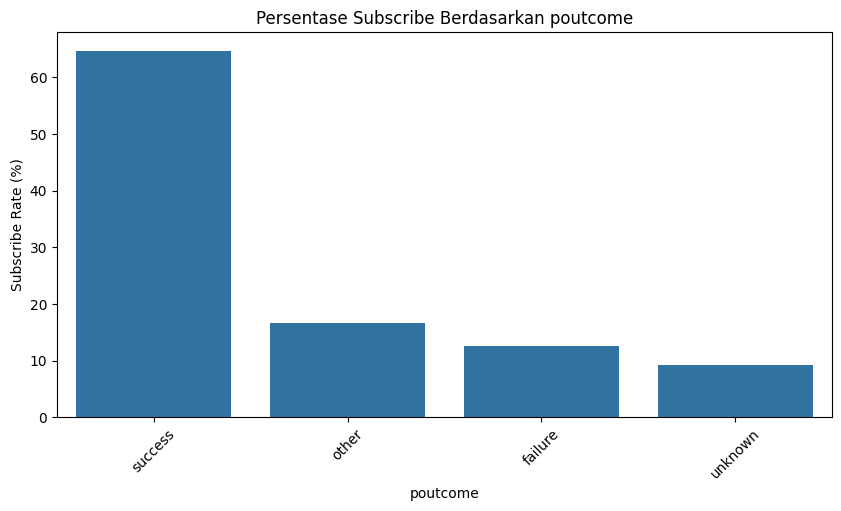

In [50]:
for col in categorical_features:
    subscribe_rate = df.groupby(col)["y"].apply(lambda x: (x == "yes").mean() * 100)
    subscribe_rate = subscribe_rate.sort_values(ascending=False)

    plt.figure(figsize=(10, 5))
    sns.barplot(x=subscribe_rate.index, y=subscribe_rate.values)
    plt.title(f"Persentase Subscribe Berdasarkan {col}")
    plt.xlabel(col)
    plt.ylabel("Subscribe Rate (%)")
    plt.xticks(rotation=45)
    plt.show()

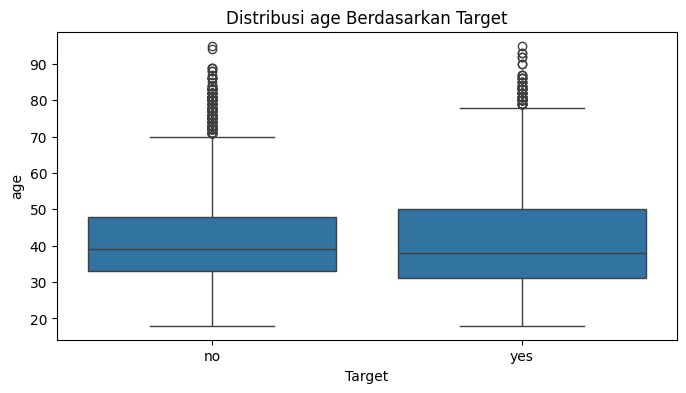

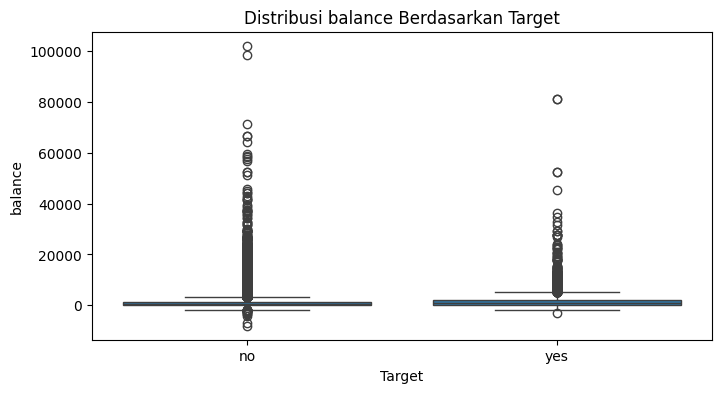

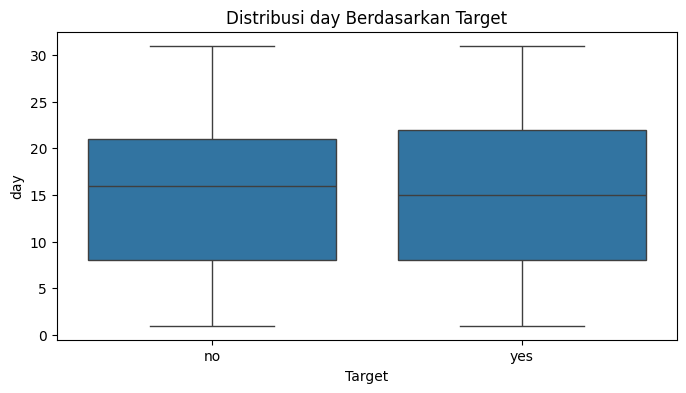

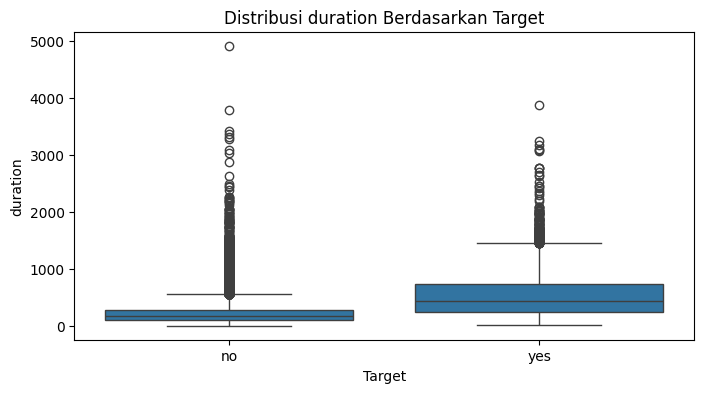

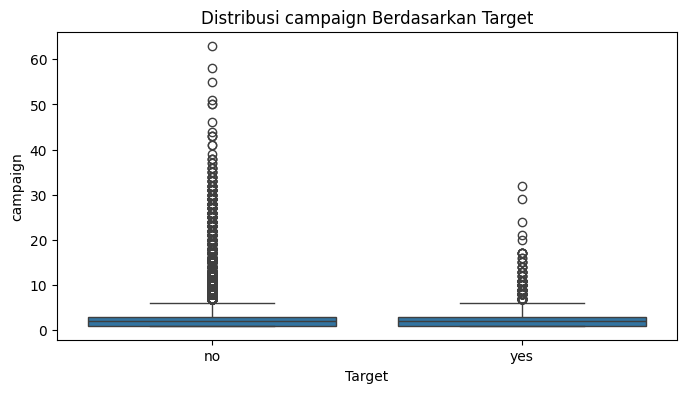

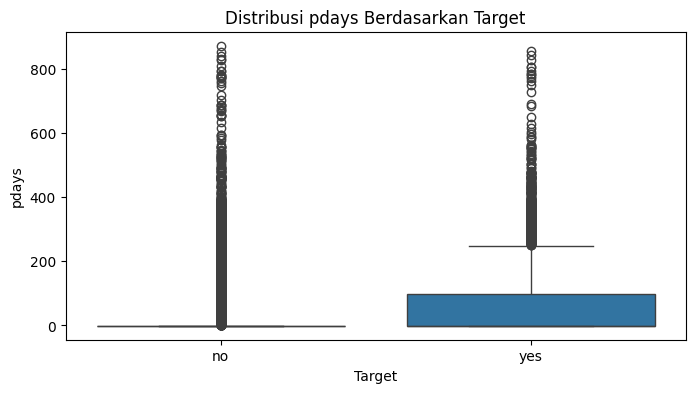

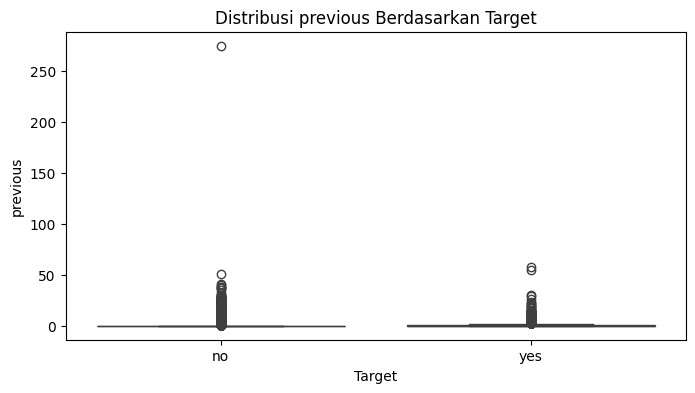

In [51]:
for col in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x="y", y=col)
    plt.title(f"Distribusi {col} Berdasarkan Target")
    plt.xlabel("Target")
    plt.ylabel(col)
    plt.show()

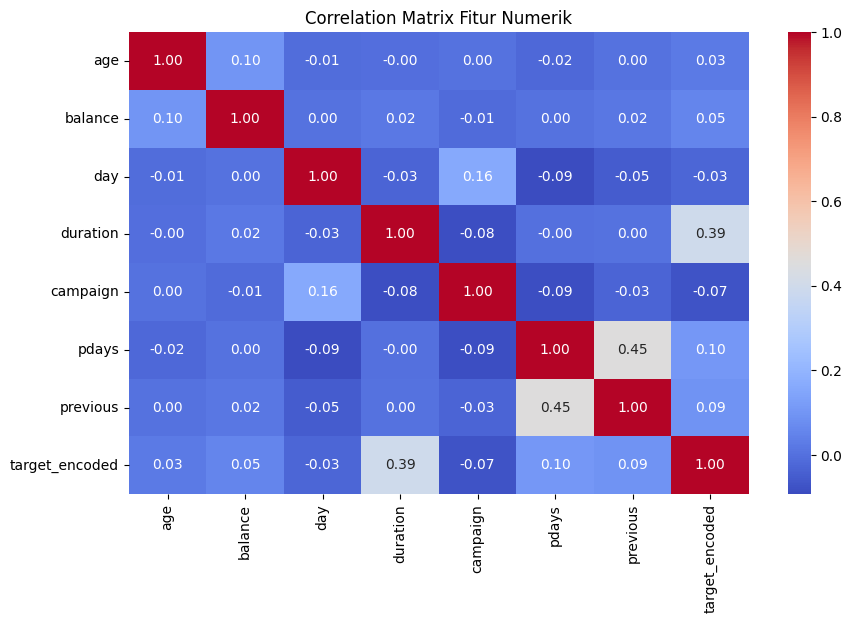

In [52]:
df_corr = df.copy()
df_corr["target_encoded"] = df_corr["y"].map({"no": 0, "yes": 1})

correlation_matrix = df_corr[numeric_columns + ["target_encoded"]].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix Fitur Numerik")
plt.show()

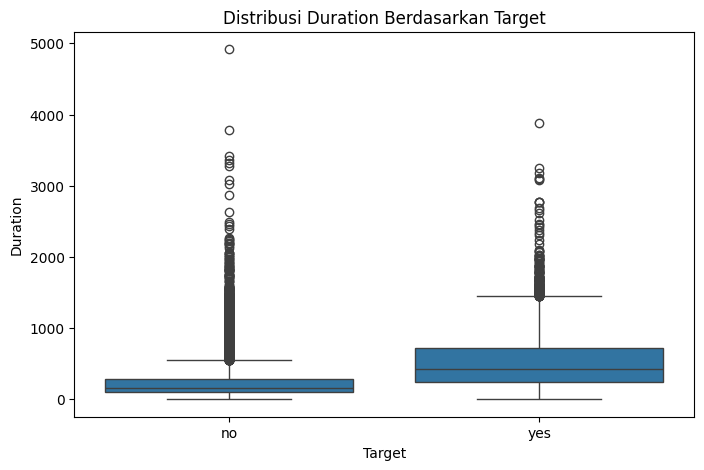

In [53]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="y", y="duration")
plt.title("Distribusi Duration Berdasarkan Target")
plt.xlabel("Target")
plt.ylabel("Duration")
plt.show()

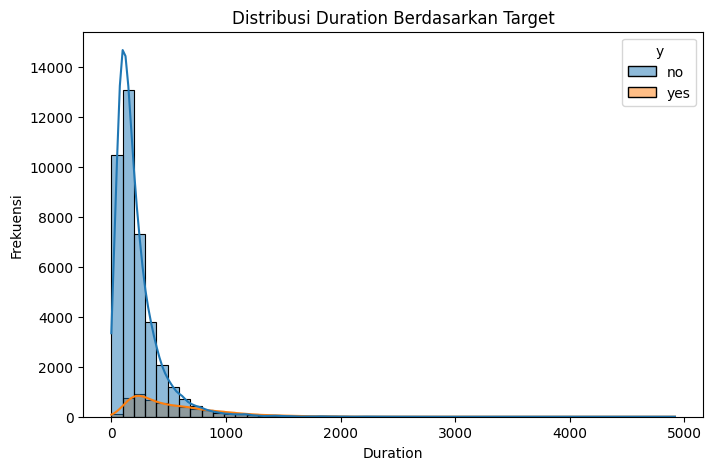

In [54]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="duration", hue="y", kde=True, bins=50)
plt.title("Distribusi Duration Berdasarkan Target")
plt.xlabel("Duration")
plt.ylabel("Frekuensi")
plt.show()

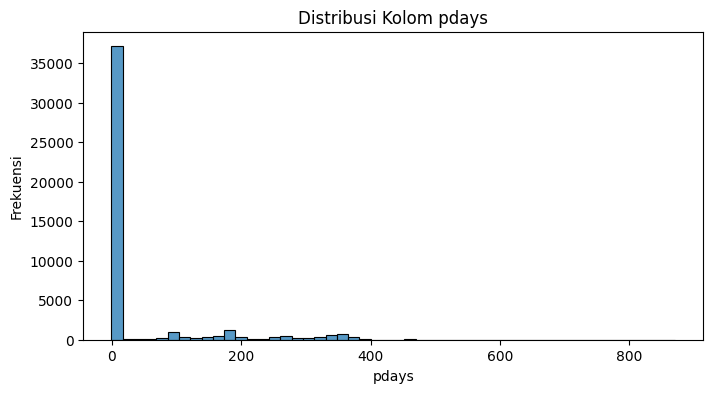

In [55]:
plt.figure(figsize=(8, 4))
sns.histplot(df["pdays"], bins=50)
plt.title("Distribusi Kolom pdays")
plt.xlabel("pdays")
plt.ylabel("Frekuensi")
plt.show()

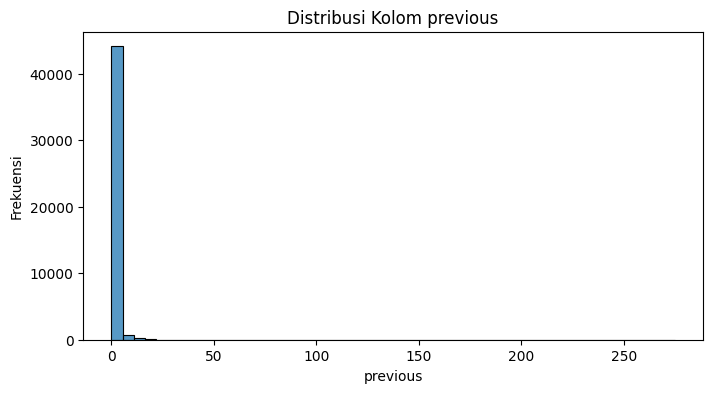

In [56]:
plt.figure(figsize=(8, 4))
sns.histplot(df["previous"], bins=50)
plt.title("Distribusi Kolom previous")
plt.xlabel("previous")
plt.ylabel("Frekuensi")
plt.show()

In [57]:
df["pdays"].value_counts().head(10)

pdays
-1      36954
 182      167
 92       147
 183      126
 91       126
 181      117
 370       99
 184       85
 364       77
 95        74
Name: count, dtype: int64

In [58]:
summary_data = {
    "Jumlah Baris": [df.shape[0]],
    "Jumlah Kolom": [df.shape[1]],
    "Jumlah Kolom Numerik": [len(numeric_columns)],
    "Jumlah Kolom Kategorikal": [len(categorical_colums)],
    "Jumlah Duplikat": [df.duplicated().sum()],
    "Jumlah Missing Value": [df.isnull().sum().sum()]
}

summary_df = pd.DataFrame(summary_data)
summary_df

,Jumlah Baris,Jumlah Kolom,Jumlah Kolom Numerik,Jumlah Kolom Kategorikal,Jumlah Duplikat,Jumlah Missing Value
0,45211,17,7,10,0,0


In [59]:
target_df

,target,count,percentage
0,no,39922,88.3
1,yes,5289,11.7


In [60]:
unknown_df[unknown_df["unknown_counts"] > 0]

,column,unknown_counts,unknown_percentage
8,poutcome,36959,81.75
6,contact,13020,28.80
2,education,1857,4.11
0,job,288,0.64


In [61]:
print("Shape dataset:", df.shape)

print("\nMissing value:")
print(df.isnull().sum())

print("\nDuplikat:")
print(df.duplicated().sum())

print("\nDistribusi target:")
print(df["y"].value_counts())
print(df["y"].value_counts(normalize=True) * 100)

print("\nUnknown value:")
for col in categorical_colums:
    unknown_count = (df[col] == "unknown").sum()
    if unknown_count > 0:
        print(col, ":", unknown_count)

print("\nKorelasi numerik dengan target:")
df_corr = df.copy()
df_corr["target_encoded"] = df_corr["y"].map({"no": 0, "yes": 1})
print(df_corr[numeric_columns + ["target_encoded"]].corr()["target_encoded"].sort_values(ascending=False))

Shape dataset: (45211, 17)

Missing value:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Duplikat:
0

Distribusi target:
y
no     39922
yes     5289
Name: count, dtype: int64
y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64

Unknown value:
job : 288
education : 1857
contact : 13020
poutcome : 36959

Korelasi numerik dengan target:
target_encoded    1.000000
duration          0.394521
pdays             0.103621
previous          0.093236
balance           0.052838
age               0.025155
day              -0.028348
campaign         -0.073172
Name: target_encoded, dtype: float64


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [62]:
df_preprocessed = df.copy()

df_preprocessed.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [63]:
df_preprocessed = df_preprocessed.drop(columns=["duration"])

df_preprocessed.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,1,-1,0,unknown,no


In [64]:
df_preprocessed["y"] = df_preprocessed["y"].map({
    "no": 0,
    "yes": 1
    })

df_preprocessed["y"].value_counts()

y
0    39922
1     5289
Name: count, dtype: int64

In [65]:
x = df_preprocessed.drop(columns=["y"])
y = df_preprocessed["y"]

print("Shape x:", x.shape)
print("Shape y:", y.shape)

Shape x: (45211, 15)
Shape y: (45211,)


In [66]:
numeric_features = x.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = x.select_dtypes(include=["object"]).columns.tolist()

print("Fitur numerik:")
print(numeric_features)

print("\nFitur kategorikal:")
print(categorical_features)

Fitur numerik:
['age', 'balance', 'day', 'campaign', 'pdays', 'previous']

Fitur kategorikal:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (36168, 15)
X_test : (9043, 15)
y_train: (36168,)
y_test : (9043,)


In [68]:
print("Distribusi y_train:")
print(y_train.value_counts(normalize=True) * 100)

print("\nDistribusi y_test:")
print(y_test.value_counts(normalize=True) * 100)

Distribusi y_train:
y
0    88.301814
1    11.698186
Name: proportion, dtype: float64

Distribusi y_test:
y
0    88.300343
1    11.699657
Name: proportion, dtype: float64


In [69]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline untuk fitur kategorikal
try:
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])
except TypeError:
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse=False))
    ])

# Gabungkan preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [70]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("X_train_processed:", X_train_processed.shape)
print("X_test_processed :", X_test_processed.shape)

X_train_processed: (36168, 50)
X_test_processed : (9043, 50)


In [71]:
numeric_feature_names = numeric_features

# Nama fitur kategorikal setelah one-hot encoding
onehot_encoder = preprocessor.named_transformers_["cat"].named_steps["onehot"]
categorical_feature_names = onehot_encoder.get_feature_names_out(categorical_features).tolist()

# Gabungkan semua nama fitur
feature_names = numeric_feature_names + categorical_feature_names

print("Jumlah fitur setelah preprocessing:", len(feature_names))
print(feature_names[:20])

Jumlah fitur setelah preprocessing: 50
['age', 'balance', 'day', 'campaign', 'pdays', 'previous', 'job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'job_unknown', 'marital_divorced', 'marital_married']


In [72]:
X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index
)

X_train_processed_df.head()

,age,balance,day,campaign,pdays,previous,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
24001,-0.460434,-0.164410,1.582124,-0.246104,-0.410910,-0.241509,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
43409,-1.589641,0.899627,-1.298384,0.398202,1.446096,2.664584,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
20669,0.292371,-0.365486,-0.458236,0.398202,-0.410910,-0.241509,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
18810,0.668773,-0.445003,1.822166,2.653271,-0.410910,-0.241509,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
23130,-0.272233,-0.361249,1.222060,2.331118,-0.410910,-0.241509,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [73]:
train_processed = X_train_processed_df.copy()
train_processed["target"] = y_train.values

test_processed = X_test_processed_df.copy()
test_processed["target"] = y_test.values

print("Train processed:", train_processed.shape)
print("Test processed :", test_processed.shape)

Train processed: (36168, 51)
Test processed : (9043, 51)


In [74]:
train_processed.head()


,age,balance,day,campaign,pdays,previous,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,...,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown,target
24001,-0.460434,-0.164410,1.582124,-0.246104,-0.410910,-0.241509,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
43409,-1.589641,0.899627,-1.298384,0.398202,1.446096,2.664584,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1
20669,0.292371,-0.365486,-0.458236,0.398202,-0.410910,-0.241509,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1
18810,0.668773,-0.445003,1.822166,2.653271,-0.410910,-0.241509,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
23130,-0.272233,-0.361249,1.222060,2.331118,-0.410910,-0.241509,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0


In [75]:
test_processed.head()

,age,balance,day,campaign,pdays,previous,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,...,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown,target
1392,-0.084032,-0.236433,-0.938321,-0.246104,-0.41091,-0.241509,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
7518,0.292371,-0.321816,1.702145,-0.246104,-0.41091,-0.241509,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
12007,-0.930937,-0.328986,0.501933,0.720354,-0.41091,-0.241509,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
5536,-0.460434,-0.231544,0.861997,0.398202,-0.41091,-0.241509,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
29816,-0.648635,0.181035,-1.418405,-0.568256,-0.41091,-0.241509,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0


In [80]:
output_dir = "C:/Users/titop/OneDrive/Dokumen/Dicoding/Pijak/Membangun Sistem Machine Learning/SMSML_Tito Purwana Sasmita/Preprocessing/Bank_preprocessing"

os.makedirs(output_dir, exist_ok=True)

train_processed_path = os.path.join(output_dir, "train_preprocessed.csv")
test_processed_path = os.path.join(output_dir, "test_preprocessed.csv")
preprocessor_path = os.path.join(output_dir, "preprocessor.joblib")

train_processed.to_csv(train_processed_path, index=False)
test_processed.to_csv(test_processed_path, index=False)

joblib.dump(preprocessor, preprocessor_path)

print("Dataset train berhasil disimpan di:", train_processed_path)
print("Dataset test berhasil disimpan di :", test_processed_path)
print("Preprocessor berhasil disimpan di  :", preprocessor_path)

Dataset train berhasil disimpan di: C:/Users/titop/OneDrive/Dokumen/Dicoding/Pijak/Membangun Sistem Machine Learning/SMSML_Tito Purwana Sasmita/Preprocessing/Bank_preprocessing\train_preprocessed.csv
Dataset test berhasil disimpan di : C:/Users/titop/OneDrive/Dokumen/Dicoding/Pijak/Membangun Sistem Machine Learning/SMSML_Tito Purwana Sasmita/Preprocessing/Bank_preprocessing\test_preprocessed.csv
Preprocessor berhasil disimpan di  : C:/Users/titop/OneDrive/Dokumen/Dicoding/Pijak/Membangun Sistem Machine Learning/SMSML_Tito Purwana Sasmita/Preprocessing/Bank_preprocessing\preprocessor.joblib


In [81]:
os.listdir(output_dir)

['preprocessor.joblib', 'test_preprocessed.csv', 'train_preprocessed.csv']

In [82]:
train_check = pd.read_csv(train_processed_path)
test_check = pd.read_csv(test_processed_path)

print("Train shape:", train_check.shape)
print("Test shape :", test_check.shape)

print("\nMissing value train:", train_check.isnull().sum().sum())
print("Missing value test :", test_check.isnull().sum().sum())

print("\nDistribusi target train:")
print(train_check["target"].value_counts(normalize=True) * 100)

print("\nDistribusi target test:")
print(test_check["target"].value_counts(normalize=True) * 100)

Train shape: (36168, 51)
Test shape : (9043, 51)

Missing value train: 0
Missing value test : 0

Distribusi target train:
target
0    88.301814
1    11.698186
Name: proportion, dtype: float64

Distribusi target test:
target
0    88.300343
1    11.699657
Name: proportion, dtype: float64
